# KPI Anomaly Detection Demo

This notebook demonstrates a simple approach for detecting anomalous KPI behavior in telecom network data using Python and pandas.

Wireless networks generate large volumes of telemetry including accessibility, retainability, throughput and signal quality metrics. Engineers must identify when these metrics degrade and determine which sites require investigation.

This prototype illustrates a simple rule-based anomaly detection approach that could be extended for automated network intelligence workflows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Example hourly KPI telemetry
data = {
    "hour": list(range(1, 13)),
    "accessibility": [99.2, 99.1, 99.3, 98.9, 99.0, 97.8, 97.5, 98.0, 99.1, 99.0, 98.8, 99.2],
    "retainability": [99.5, 99.4, 99.6, 99.5, 99.4, 98.7, 98.5, 98.8, 99.3, 99.4, 99.2, 99.5],
    "throughput_mbps": [82, 80, 84, 79, 81, 42, 38, 45, 78, 80, 77, 83]
}

df = pd.DataFrame(data)
df

,hour,accessibility,retainability,throughput_mbps
0,1,99.2,99.5,82
1,2,99.1,99.4,80
2,3,99.3,99.6,84
3,4,98.9,99.5,79
4,5,99.0,99.4,81
5,6,97.8,98.7,42
6,7,97.5,98.5,38
7,8,98.0,98.8,45
8,9,99.1,99.3,78
9,10,99.0,99.4,80


## Anomaly Detection Logic

In this simple example, we flag potential anomalies when:

• Accessibility drops below 98.5%  
• Retainability drops below 99.0%  
• Throughput drops below 50 Mbps  

In real networks these thresholds would be learned dynamically or tuned per market.

In [3]:
# Flag KPI anomalies
df["anomaly"] = (
    (df["accessibility"] < 98.5) |
    (df["retainability"] < 99.0) |
    (df["throughput_mbps"] < 50)
)

df

,hour,accessibility,retainability,throughput_mbps,anomaly
0,1,99.2,99.5,82,False
1,2,99.1,99.4,80,False
2,3,99.3,99.6,84,False
3,4,98.9,99.5,79,False
4,5,99.0,99.4,81,False
5,6,97.8,98.7,42,True
6,7,97.5,98.5,38,True
7,8,98.0,98.8,45,True
8,9,99.1,99.3,78,False
9,10,99.0,99.4,80,False


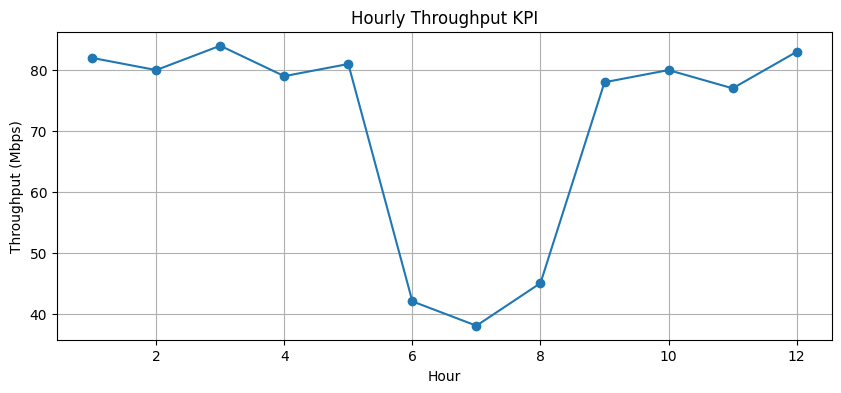

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(df["hour"], df["throughput_mbps"], marker="o")
plt.xlabel("Hour")
plt.ylabel("Throughput (Mbps)")
plt.title("Hourly Throughput KPI")
plt.grid(True)
plt.show()